In [8]:
#> imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, NullFormatter
from matplotlib.ticker import PercentFormatter
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from matplotlib.colors import LinearSegmentedColormap
import sys
import glob

In [9]:
#> opening obs file
obs_file = 'all_obs_quads.csv'
obs_df = pd.read_csv(obs_file)

In [10]:
def plot(name, images):
    fontsize=15
    fig, ax = plt.subplots(1,1,figsize=(4,4))
    ax.set_xlabel(r'$\mathbf{\Delta RA}$', fontsize=fontsize, labelpad=5)
    ax.set_ylabel(r'$\mathbf{\Delta DEC}$', fontsize=fontsize)
    ax.set_title(f'{name}', fontsize=fontsize, fontweight='bold')
    ax.set_box_aspect(1)

    for i, im in enumerate(images):
        ax.scatter(im[0], im[1], marker=f'${i+1}$')
        ax.scatter(0, 0, marker='+', c='k')
        # ax.scatter(r, d, c='k', marker='.')
    # ax.scatter(0,0,marker='X', c='k')
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    m = max(abs(xlim[0]), abs(xlim[1]),
            abs(ylim[0]), abs(ylim[1]))
    
    ax.set_xlim(-m, m)
    ax.set_ylim(-m, m)

    ax.xaxis.set_inverted(True) 
    
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.grid(ls=':', alpha=0.5, which='both')

    plt.savefig(f'./figs/{name}-arrival.png', bbox_inches='tight', dpi=100)
    plt.show()

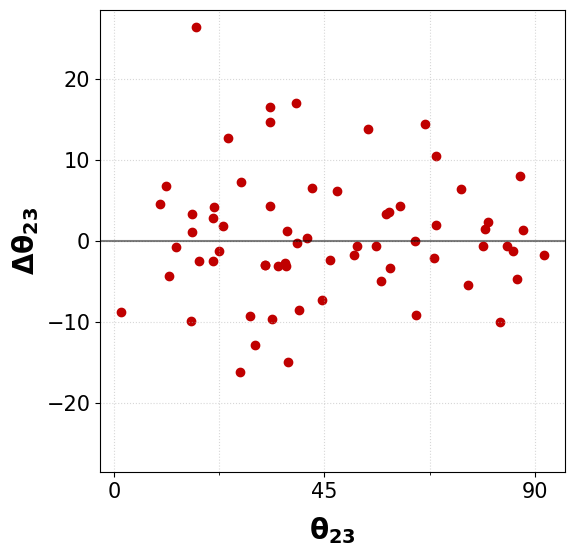

In [12]:
#> plotting 2D FSQ

c = '#C00000'
fontsize=20
nquads = len(obs_df['t23'].to_numpy())
fig, ax = plt.subplots(1, 1, figsize=(6,6))

# ax.set_title(f'All Quad Lenses (N={nquads})', fontsize=fontsize, fontweight='bold')
ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=fontsize, labelpad=10)
ax.set_ylabel(r'$\mathbf{\Delta\theta_{23}}$', fontsize=fontsize)
ax.axhline(0, c='k', alpha=0.5)

ax.scatter(obs_df['t23'], obs_df['dt23'], c=c)

miny, maxy = ax.get_ylim()
bound = max(abs(miny), maxy)
ax.set_ylim(-bound, bound)

# ax.set_xticklabels([])
# ax.set_yticklabels({})
ax.set_xticks([0, 45, 90])
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(ls=':', alpha=0.5, which='both')
ax.tick_params(axis='both', which='major', labelsize=15)

plt.savefig('./figs/obs_2DFSQ_labels.png', bbox_inches='tight', dpi=100)
plt.show()

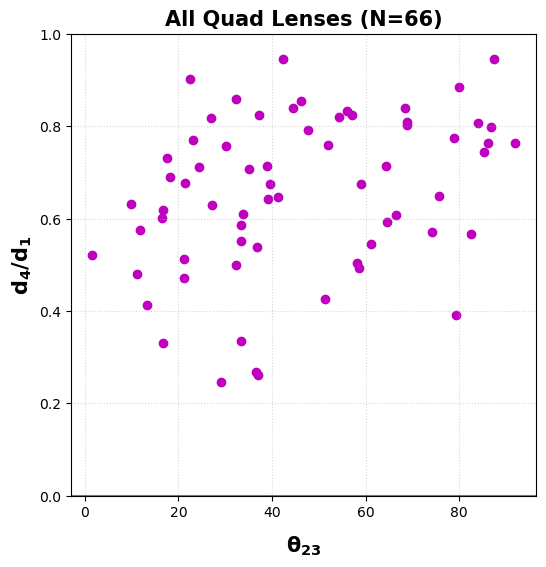

In [13]:
#> plotting 2D FSQ
fontsize=15
nquads = len(obs_df['t23'].to_numpy())
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.grid(ls=':', alpha=0.5)
ax.set_title(f'All Quad Lenses (N={nquads})', fontsize=fontsize, fontweight='bold')
ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=fontsize, labelpad=10)
ax.set_ylabel(r'$\mathbf{d_4/d_1}$', fontsize=fontsize)
ax.axhline(0, c='k', alpha=0.5)

ax.scatter(obs_df['t23'], obs_df['d4/d1'], c='m')

miny, maxy = ax.get_ylim()
ax.set_ylim(0,1)

plt.savefig('./figs/obs_d4d1t23.png', bbox_inches='tight', dpi=100)
plt.show()

                      Name         t12        t23         t34     d2/d1  \
3          ATLASJ2344-3056  162.337535  78.863321  177.402246  1.037732   
13  DESJ040559.80-330851.4  156.685206  79.893117  178.993858  0.918664   
25             HE0435-1223  159.123527  86.097362  196.509519  0.746094   
47           SDSS1011+0143  190.263815  91.925410  176.369058  0.929206   
55          SDSSJ1538+5817  117.672632  87.392291  207.349876  0.976631   

       d3/d1     d4/d1      dt23       d01       d02       d03       d04  \
3   0.986751  0.773852 -0.623941  0.528391  0.548328  0.521390  0.408896   
13  0.920497  0.884921  2.240385  0.752322  0.691131  0.692510  0.665745   
25  0.762895  0.763561 -4.732700  1.477943  1.102684  1.127516  1.128499   
47  0.854616  0.764456 -1.718697  2.070676  1.924084  1.769633  1.582940   
55  0.954369  0.946148  1.287211  1.015135  0.991413  0.968814  0.960469   

       d3/d2  
3   0.950872  
13  1.001995  
25  1.022519  
47  0.919727  
55  0.977205  


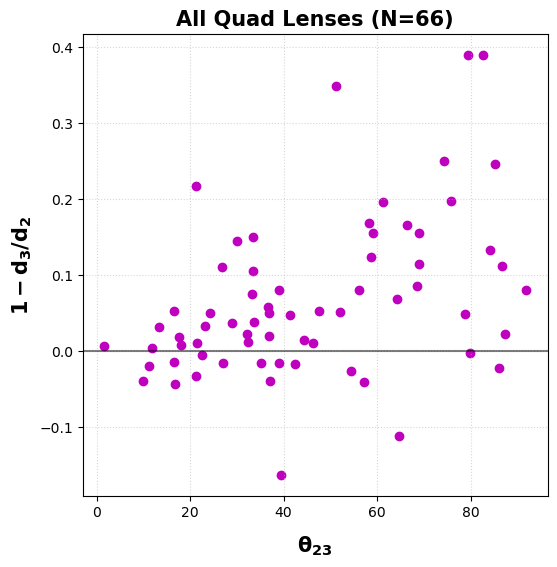

In [15]:
#> plotting 2D FSQ
fontsize=15
nquads = len(obs_df['t23'].to_numpy())
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.grid(ls=':', alpha=0.5)
ax.set_title(f'All Quad Lenses (N={nquads})', fontsize=fontsize, fontweight='bold')
ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=fontsize, labelpad=10)
ax.set_ylabel(r'$\mathbf{1-d_3/d_2}$', fontsize=fontsize)
ax.axhline(0, c='k', alpha=0.5)

ax.scatter(obs_df['t23'], 1-obs_df['d3/d2'], c='m')

# print(obs[ 1-obs['d3/d2'] < -0.4 ])
print(obs_df[ (1-obs_df['d3/d2'] < 0.1) & (1-obs_df['d3/d2'] > -0.1) & (obs_df['t23'] > 75) ] )

miny, maxy = ax.get_ylim()

plt.savefig('./figs/obs_d3d2t23.png', bbox_inches='tight', dpi=100)
plt.show()

## **Bisector Angles**

In [16]:
obs_df['b12'] = obs_df['t12']/2
obs_df['b34'] = obs_df['t12'] - obs_df['t23'] + obs_df['t34']/2
obs_df['b12-b34'] = obs_df['b34']-obs_df['b12']
obs_df

,Name,t12,t23,t34,d2/d1,d3/d1,d4/d1,dt23,d01,d02,d03,d04,d3/d2,b12,b34,b12-b34
0,1810.01633,148.668900,61.229272,157.392502,0.929732,0.747339,0.545220,4.266853,2.091220,1.944274,1.562850,1.140175,0.803822,74.334450,166.135879,91.801429
1,2MASSJ11344050-2103230,160.990859,79.388255,176.174471,0.905398,0.552758,0.392132,1.421837,1.959039,1.773709,1.082875,0.768202,0.610514,80.495429,169.689839,89.194410
2,2MASXJ01471020+4630433,67.496249,33.282576,176.414406,1.053678,0.974821,0.551357,4.304327,2.131754,2.246182,2.078077,1.175357,0.925160,33.748124,122.420876,88.672752
3,ATLASJ2344-3056,162.337535,78.863321,177.402246,1.037732,0.986751,0.773852,-0.623941,0.528391,0.548328,0.521390,0.408896,0.950872,81.168767,172.175337,91.006569
4,B0128+437,166.642462,33.726889,114.638397,0.773541,0.743710,0.609925,-9.702828,0.311082,0.240635,0.231355,0.189737,0.961436,83.321231,190.234772,106.913540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,WFI2026-4536,167.866845,30.079459,111.735674,0.779213,0.666326,0.756942,-12.914943,0.824742,0.642650,0.549547,0.624282,0.855127,83.933422,193.655222,109.721800
62,WFI2033-4723,134.763345,33.443944,122.518557,0.904061,0.809099,0.587003,16.479074,1.440477,1.302279,1.165489,0.845564,0.894961,67.381672,162.578679,95.197007
63,WG0214-2105,172.587701,68.865969,145.655630,0.890399,0.788669,0.802560,1.926882,0.981781,0.874176,0.774300,0.787937,0.885748,86.293851,176.549547,90.255697
64,WG2100-4452,124.692279,23.198296,137.406381,0.943367,0.912157,0.770706,1.836102,1.434103,1.352885,1.308127,1.105272,0.966917,62.346140,170.197174,107.851034


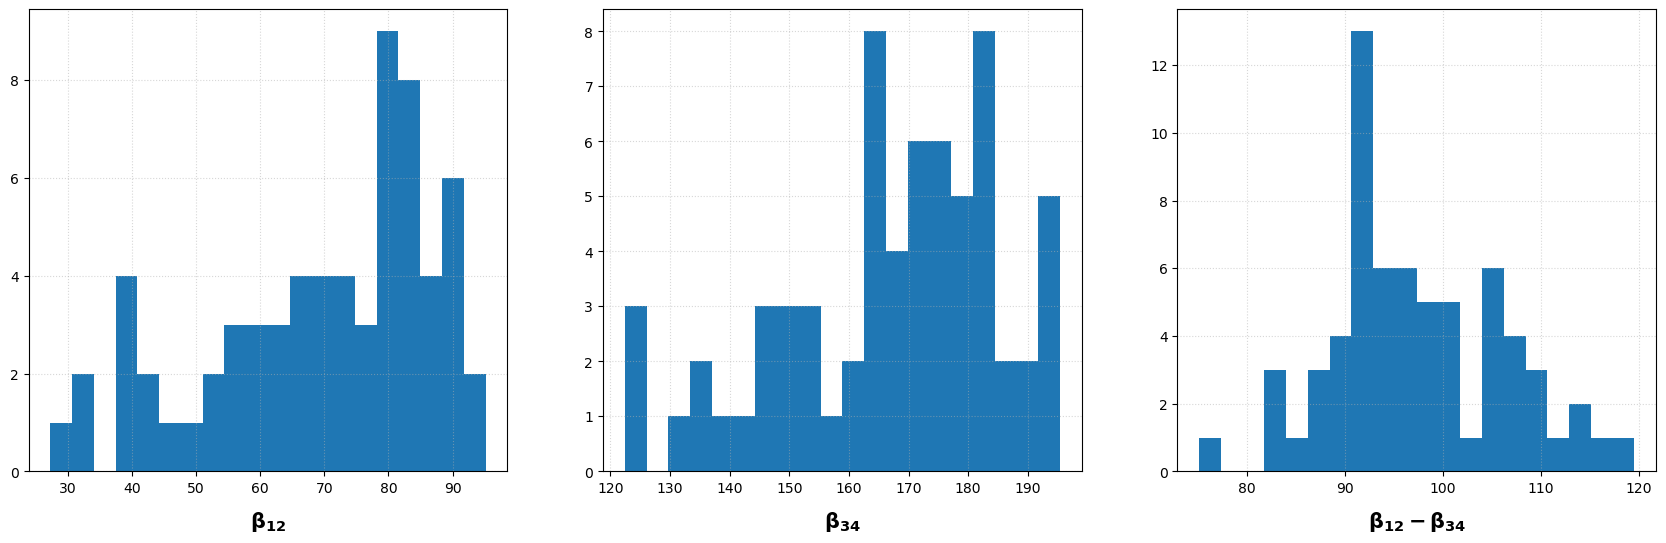

In [17]:
#> initializing plot
fig, axes = plt.subplots(1,3,figsize=(3*6+3, 6))
bins=20
keys = ['b12', 'b34', 'b12-b34']
labels = [r'$\mathbf{\beta_{12}}$', r'$\mathbf{\beta_{34}}$', r'$\mathbf{\beta_{12}-\beta_{34}}$']
for key, label, ax in zip(keys, labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_xlabel(label, fontsize=15, labelpad=10)
    ax.hist(obs_df[key], bins)
plt.savefig('./figs/obs_bisector_histograms.png', bbox_inches='tight', dpi=100)

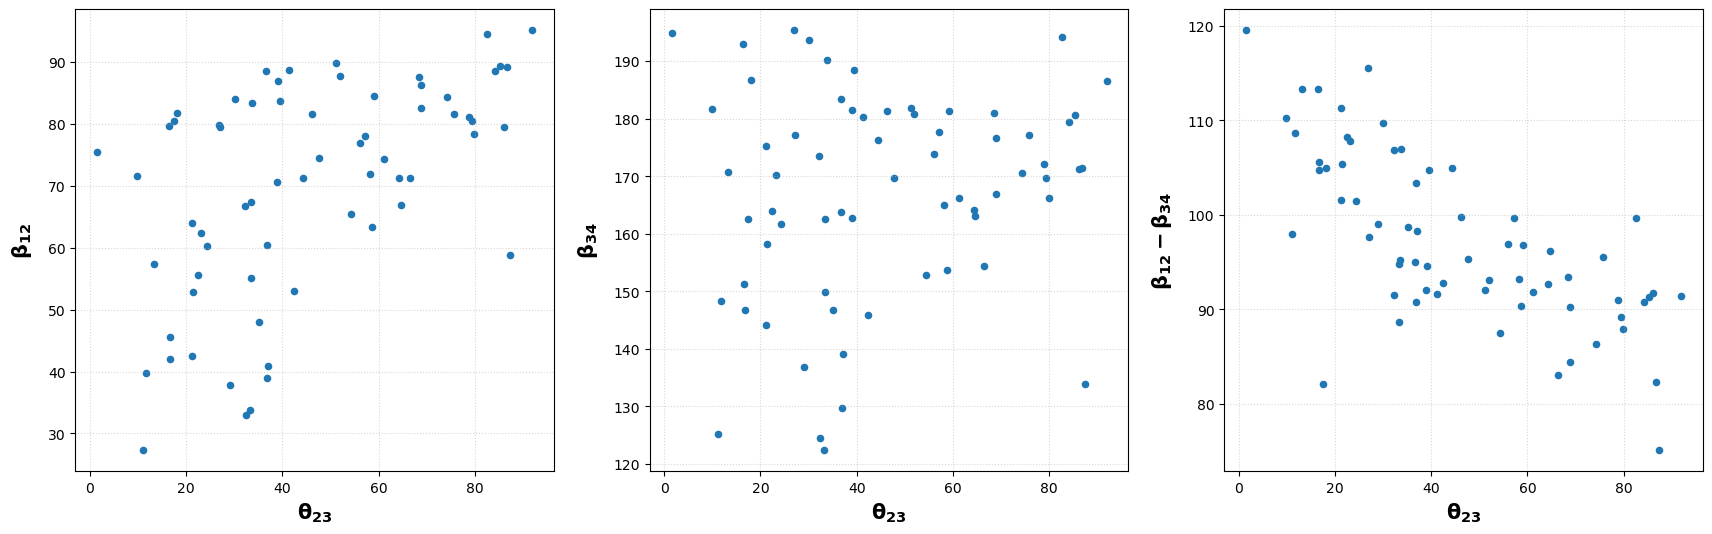

In [18]:
#> initializing plot
fig, axes = plt.subplots(1,3,figsize=(3*6+3, 6))
bins = 20
keys = ['b12', 'b34', 'b12-b34']
labels = [r'$\mathbf{\beta_{12}}$', r'$\mathbf{\beta_{34}}$', r'$\mathbf{\beta_{12}-\beta_{34}}$']
for key, label, ax in zip(keys, labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_ylabel(label, fontsize=15, labelpad=10)
    ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=15)
    ax.scatter(obs_df['t23'], obs_df[key], bins)
plt.savefig('./figs/obs_bisector_t34.png', bbox_inches='tight', dpi=100)

## **Histogram of Lensing Observables**

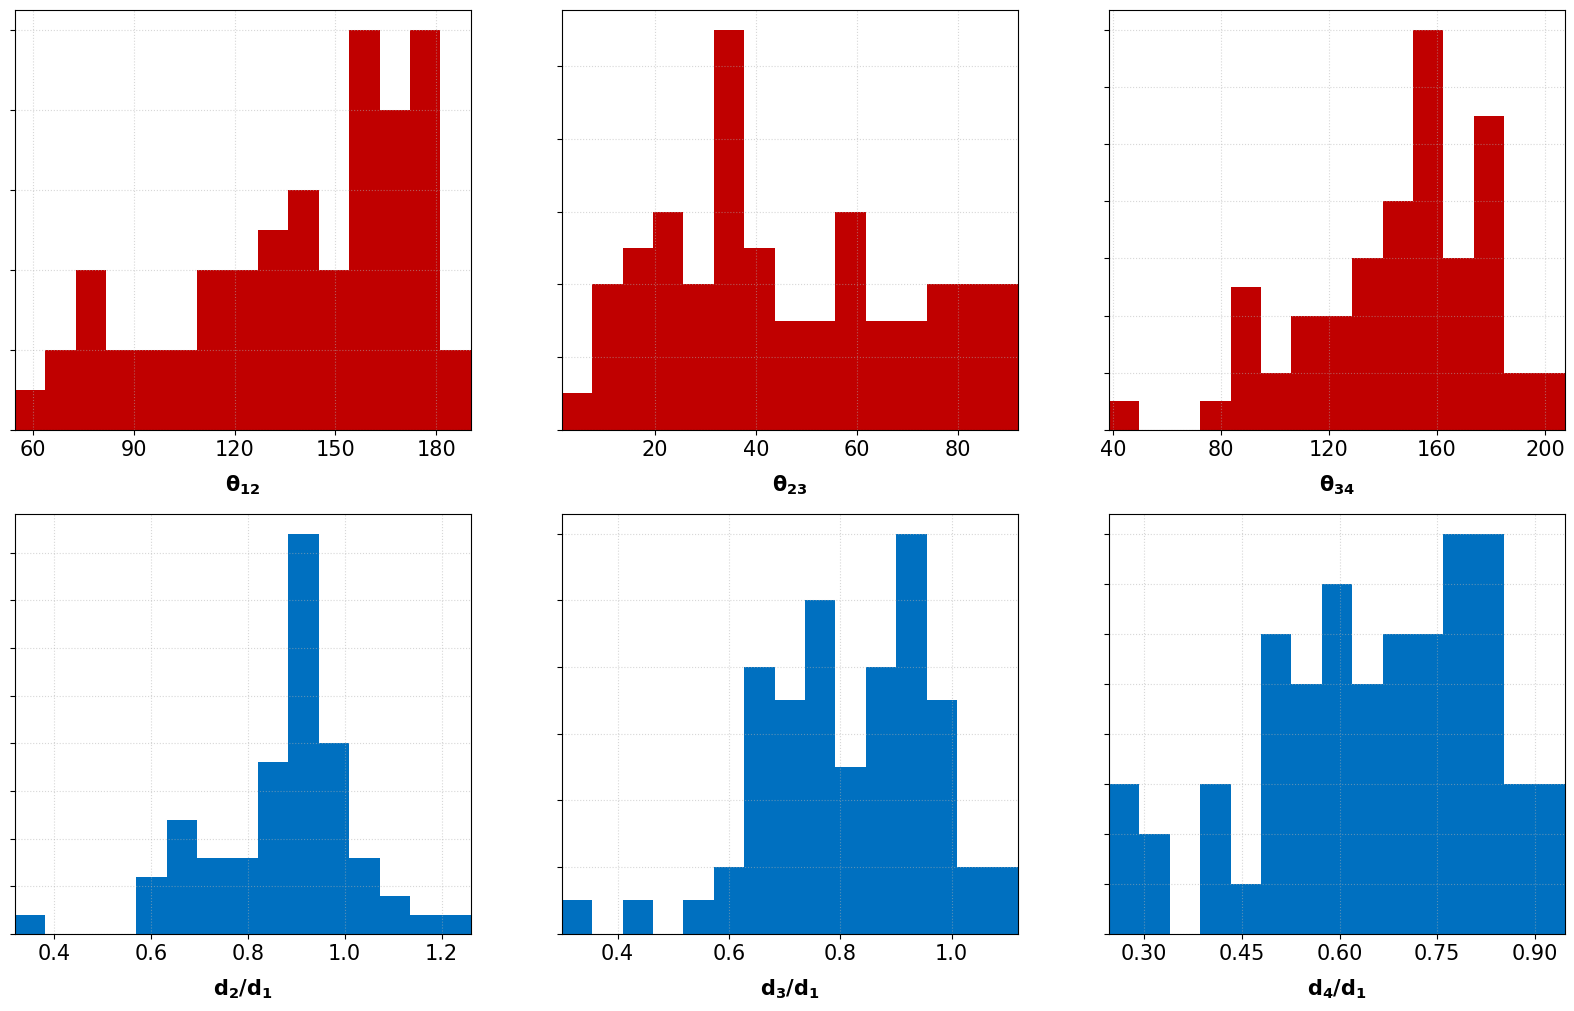

In [19]:
#> initializing plots
keys = ['t12', 't23', 't34', 'd2/d1', 'd3/d1', 'd4/d1', 'dt23']
labels = [r'$\mathbf{\theta_{12}}$', r'$\mathbf{\theta_{23}}$', r'$\mathbf{\theta_{34}}$', 
          r'$\mathbf{d_2/d_1}$', r'$\mathbf{d_3/d_1}$', r'$\mathbf{d_4/d_1}$', 
          r'$\mathbf{\Delta\theta_{23}}$']

c = '#C00000'
bb = '#0070C0'

fig, axes = plt.subplots(2, 3, figsize=(3*6+2, 2*6))
bins = 15
for key, label, ax in zip(keys, labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_xlabel(label, fontsize=15, labelpad=10)
    ax.set_xlim(min(obs_df[key]), max(obs_df[key]))
    if 'd' in key: color=bb
    else: color = c
    ax.hist(obs_df[key], bins, facecolor=color)
    ax.set_yticklabels([])
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig('./figs/obs_histograms.png', bbox_inches='tight', dpi=100)
plt.show()

## **Histogram of Mock Quads**

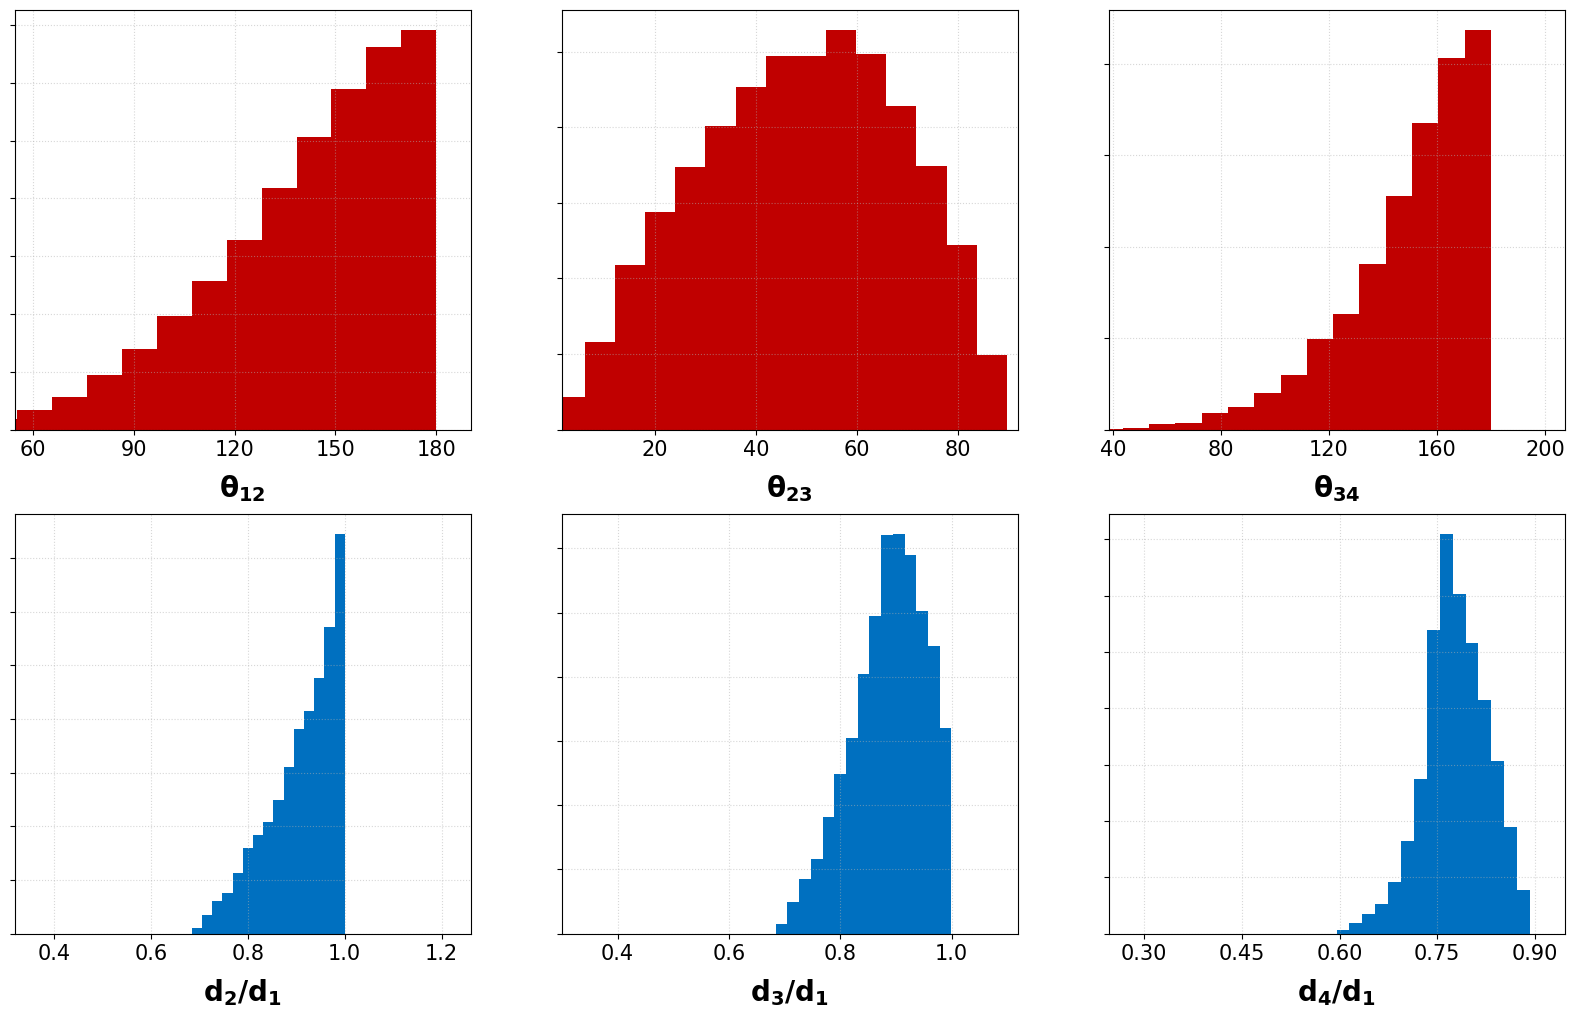

,t12,t23,t34,d2/d1,d3/d1,d4/d1,dt23
0,131.72177,28.130984,138.545681,0.882684,0.879261,0.759901,-0.179298
1,162.164425,70.169665,163.378494,0.937991,0.889813,0.833412,-0.042614
2,121.035688,38.604116,158.023263,0.941365,0.932722,0.756097,-0.120051
3,169.326011,45.561585,113.577137,0.789935,0.780307,0.763292,-0.045816
4,169.076345,76.48493,166.515594,0.948335,0.885757,0.850627,-0.041111
...,...,...,...,...,...,...,...
9995,167.32921,71.308494,159.793669,0.924194,0.874916,0.835879,-0.042559
9996,145.610485,52.80852,154.933937,0.916143,0.895301,0.793813,-0.099289
9997,158.981758,38.166801,118.925578,0.80786,0.801453,0.763822,-0.10462
9998,100.982564,6.079172,141.346774,0.928454,0.928318,0.727655,-0.227298


In [21]:
file = '2605211426fsq_q0.85.npy'
file = '2605281545fsq_q0.75.npy'
from matplotlib.ticker import MaxNLocator
data = np.load(file, allow_pickle=True)
data
df = pd.DataFrame(data, columns=['t12', 't23', 't34', 'd2/d1', 'd3/d1' ,'d4/d1', 'dt23'])
df
c = '#C00000'
bb = '#0070C0'
fig, axes = plt.subplots(2, 3, figsize=(3*6+2, 2*6))
bins = 15
fontsize=20
for key, label, ax in zip(df.keys(), labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_xlabel(label, fontsize=fontsize, labelpad=10)
    ax.set_xlim(min(obs_df[key]), max(obs_df[key]))
    if 'd' in key: color=bb
    else: color = c
    ax.hist(df[key], bins, facecolor=color)
    ax.set_yticklabels([])
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.tick_params(axis='both', which='major', labelsize=15)
plt.savefig('./figs/mock_histograms.png', bbox_inches='tight', dpi=100)
plt.show()

df

0 10000


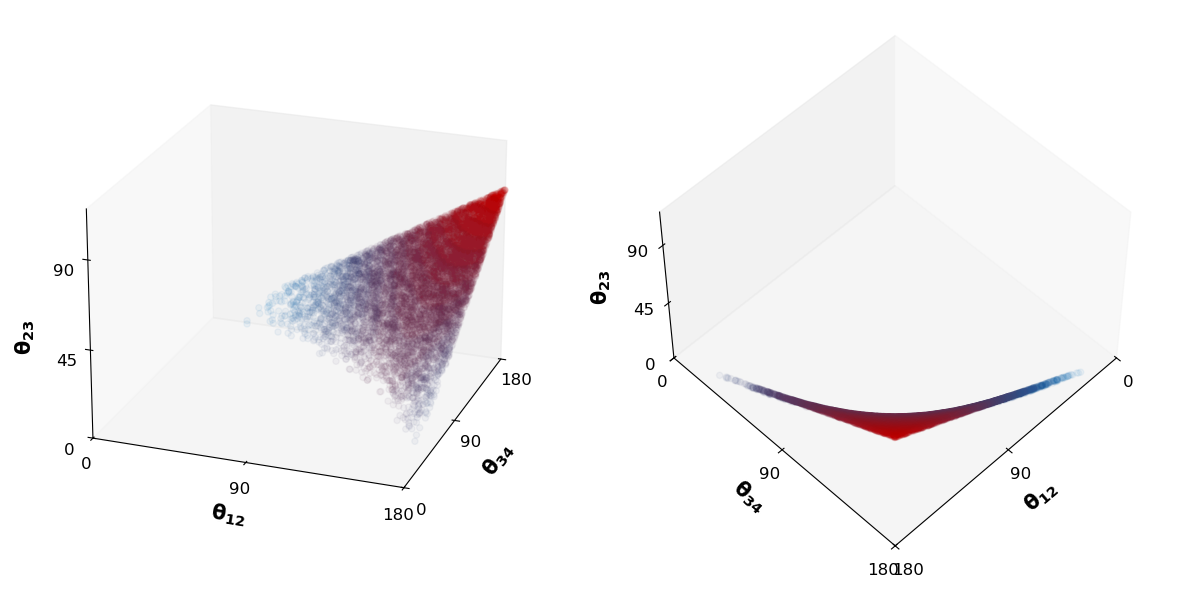

In [22]:
# DISTANCE RATIOS 3D PLOT

# initializing figure
fig = plt.figure(figsize=(12,6))

cc = '#C00000'
bb = '#0070C0'
colors = [(0.9, 0, 0.9), (0, 0.8, 0.0)] # first color is black, last is red
colors = [bb, cc]
cm = LinearSegmentedColormap.from_list("Custom", colors, N=20)

# FIRST GRAPH - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
ax = fig.add_subplot(1,2,1,projection='3d')
ax.grid(False)

# flips zaxis labels
tmp_planes = ax.zaxis._PLANES 
ax.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])

# ax.set_title('Distribution of Distance Ratios', fontweight='bold', size=12, y=0.95)
ax.set_xlabel(r'$\mathbf{\theta_{12}}$', fontweight='bold', size=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\theta_{34}}$', fontweight='bold', size=15, labelpad=10)
ax.zaxis.set_rotate_label(False) 
ax.set_zlabel(r'$\mathbf{\theta_{23}}$', fontweight='bold', size=15, labelpad=10, rotation=90)

ticks = np.arange(0, 225, 45)
ticks2 = np.arange(0, 225, 90)
zticks = np.arange(0, 135, 45)
ax.set_xticks(ticks2); ax.set_yticks(ticks2); ax.set_zticks(zticks)
ax.set_xlim(0, 180); ax.set_ylim(0, 180); ax.set_zlim(0, 115)
ax.tick_params(labelsize=12)

cm = LinearSegmentedColormap.from_list("Custom", colors, N=20)

# plotting!
q = 0
pts = 10000
srt = pts*q
end = srt + pts
print(srt, end)
x, y, z = df['t12'][srt:end].astype(float), df['t34'][srt:end].astype(float), df['t23'][srt:end].astype(float)
zz = df['d4/d1'][srt:end].astype(float)
ax.scatter(x, y, z, alpha=0.05, cmap=cm, c=zz)

ax.view_init(elev=22.5, azim=-70)
ax.set_box_aspect(None, zoom=0.88)

# SECOND GRAPH - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
ax = fig.add_subplot(1,2,2,projection='3d')
ax.grid(False)

# flips zaxis labels
tmp_planes = ax.zaxis._PLANES 
ax.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])

# ax.set_title('Distribution of Distance Ratios', fontweight='bold', size=12, y=0.95)
ax.set_xlabel(r'$\mathbf{\theta_{12}}$', fontweight='bold', size=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\theta_{34}}$', fontweight='bold', size=15, labelpad=10)
ax.zaxis.set_rotate_label(False) 
ax.set_zlabel(r'$\mathbf{\theta_{23}}$', fontweight='bold', size=15, labelpad=10, rotation=90)

ticks = np.arange(0, 225, 45)
ticks2 = np.arange(0, 225, 90)
zticks = np.arange(0, 135, 45)
ax.set_xticks(ticks2); ax.set_yticks(ticks2); ax.set_zticks(zticks)
ax.set_xlim(0, 180); ax.set_ylim(0, 180); ax.set_zlim(0, 115)
ax.tick_params(labelsize=12)

ax.view_init(elev=67.5, azim=45)
ax.view_init(elev=53, azim=45)
ax.set_box_aspect(None, zoom=0.88)

cm = LinearSegmentedColormap.from_list("Custom", colors, N=100)

# plotting!
x, y, z = df['t12'][srt:end].astype(float), df['t34'][srt:end].astype(float), df['t23'][srt:end].astype(float)
zz = df['d4/d1'][srt:end].astype(float)
ax.scatter(x, y, z, alpha=0.05, cmap=cm, c=zz)

# showing & saving
fig.tight_layout()
plt.savefig('3d-image-angles.png', dpi=200, bbox_inches='tight')
plt.show()

0 10000


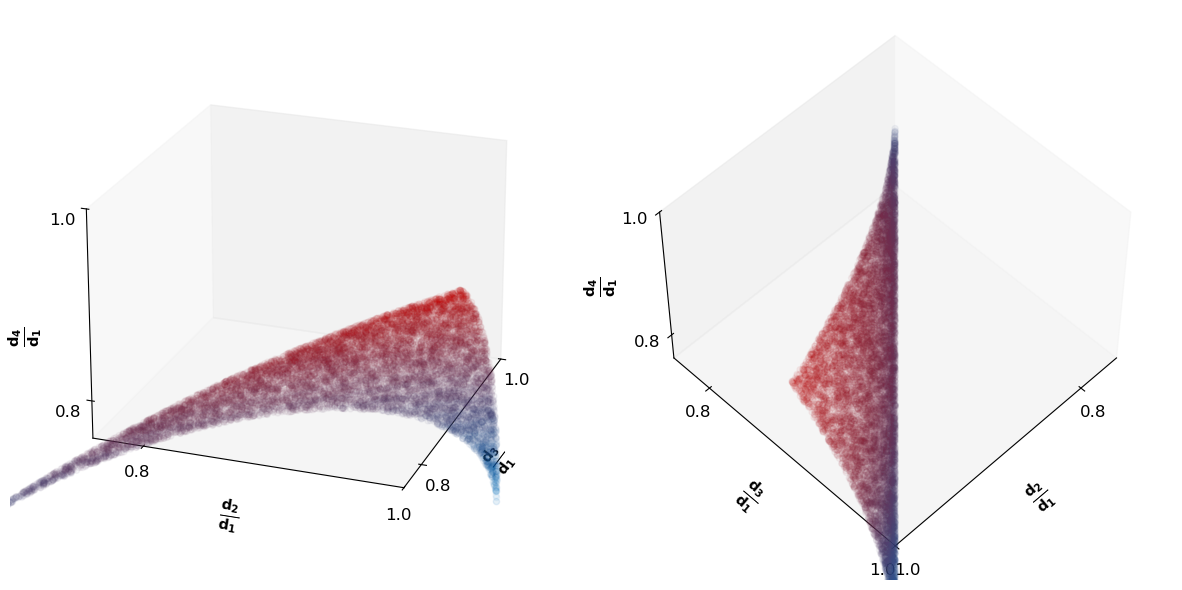

In [15]:
# DISTANCE RATIOS 3D PLOT

# initializing figure
fig = plt.figure(figsize=(12,6))

cc = '#C00000'
bb = '#0070C0'
colors = [(0.9, 0, 0.9), (0, 0.8, 0.0)] # first color is black, last is red
colors = [bb, cc]
cm = LinearSegmentedColormap.from_list("Custom", colors, N=20)

# FIRST GRAPH - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
ax = fig.add_subplot(1,2,1,projection='3d')
ax.grid(False)

# flips zaxis labels
tmp_planes = ax.zaxis._PLANES 
ax.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])

# ax.set_title('Distribution of Distance Ratios', fontweight='bold', size=12, y=0.95)
ax.set_xlabel(r'$\mathbf{\frac{d_2}{d_1}}$', fontweight='bold', size=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\frac{d_3}{d_1}}$', fontweight='bold', size=15, labelpad=10)
ax.zaxis.set_rotate_label(False) 
ax.set_zlabel(r'$\mathbf{\frac{d_4}{d_1}}$', fontweight='bold', size=15, labelpad=10, rotation=90)

edge = 0.76
ticks = np.arange(0.8, 1.3, 0.2)
ax.set_xticks(ticks); ax.set_yticks(ticks); ax.set_zticks(ticks)
ax.set_xlim(edge, 1); ax.set_ylim(edge, 1); ax.set_zlim(edge, 1)
ax.tick_params(labelsize=12)

cm = LinearSegmentedColormap.from_list("Custom", colors, N=20)

# plotting!
q = 0
pts = 10000
srt = pts*q
end = srt + pts
print(srt, end)
x, y, z = df['d2/d1'][srt:end].astype(float), df['d3/d1'][srt:end].astype(float), df['d4/d1'][srt:end].astype(float)
zz = df['d4/d1'][srt:end].astype(float)
ax.scatter(x, y, z, alpha=0.05, cmap=cm, c=zz)

ax.view_init(elev=22.5, azim=-70)
ax.set_box_aspect(None, zoom=0.88)

# SECOND GRAPH - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
ax = fig.add_subplot(1,2,2,projection='3d')
ax.grid(False)

# flips zaxis labels
tmp_planes = ax.zaxis._PLANES 
ax.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])

# ax.set_title('Distribution of Distance Ratios', fontweight='bold', size=12, y=0.95)
ax.set_xlabel(r'$\mathbf{\frac{d_2}{d_1}}$', fontweight='bold', size=15, labelpad=10)
ax.set_ylabel(r'$\mathbf{\frac{d_3}{d_1}}$', fontweight='bold', size=15, labelpad=10)
ax.zaxis.set_rotate_label(False) 
ax.set_zlabel(r'$\mathbf{\frac{d_4}{d_1}}$', fontweight='bold', size=15, labelpad=10, rotation=90)

ticks = np.arange(0.8, 1.3, 0.2)
ax.set_xticks(ticks); ax.set_yticks(ticks); ax.set_zticks(ticks)
ax.set_xlim(edge, 1); ax.set_ylim(edge, 1); ax.set_zlim(edge, 1)
ax.tick_params(labelsize=12)

ax.view_init(elev=67.5, azim=45)
ax.view_init(elev=53, azim=45)
ax.set_box_aspect(None, zoom=0.88)

cm = LinearSegmentedColormap.from_list("Custom", colors, N=100)

# plotting!
x, y, z = df['d2/d1'][srt:end].astype(float), df['d3/d1'][srt:end].astype(float), df['d4/d1'][srt:end].astype(float)
zz = df['d4/d1'][srt:end].astype(float)
ax.scatter(x, y, z, alpha=0.05, cmap=cm, c=zz)

# showing & saving
fig.tight_layout()
plt.savefig('3d-image-distance-ratios_0.75.png', dpi=200, bbox_inches='tight')
plt.show()

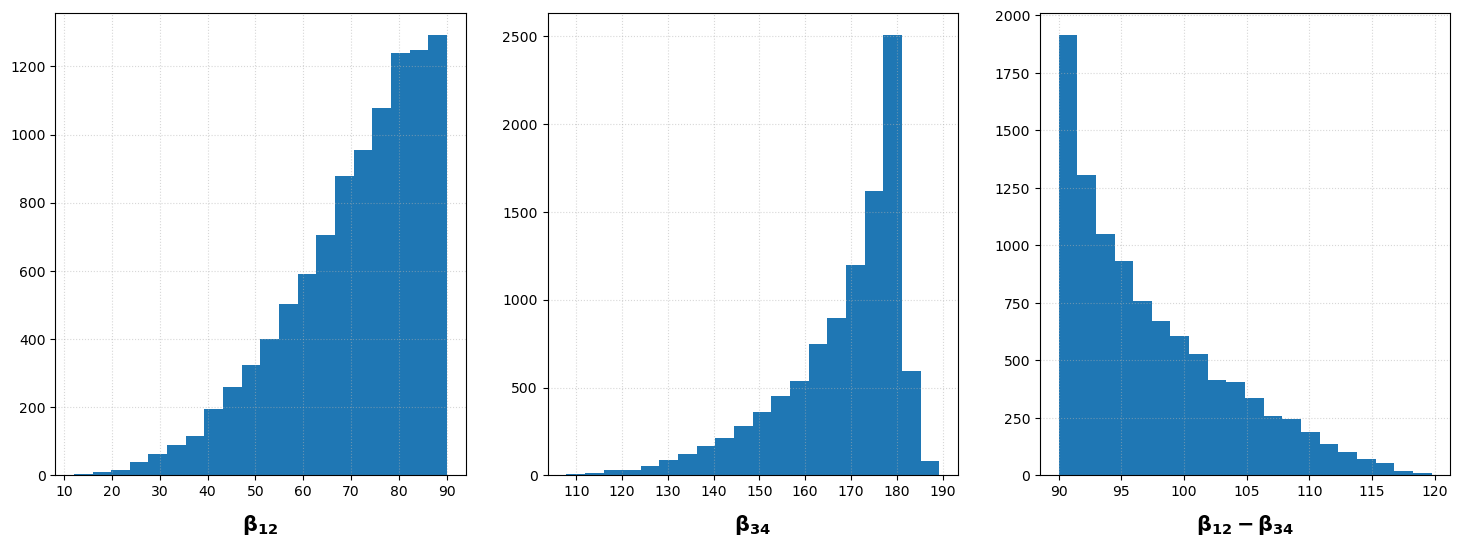

In [23]:
df['b12'] = df['t12']/2
df['b34'] = df['t12'] - df['t23'] + df['t34']/2
df['b12-b34'] = df['b34'] - df['b12']
df

#> initializing plot
fig, axes = plt.subplots(1,3,figsize=(3*6, 6))
bins=20
keys = ['b12', 'b34', 'b12-b34']
labels = [r'$\mathbf{\beta_{12}}$', r'$\mathbf{\beta_{34}}$', r'$\mathbf{\beta_{12}-\beta_{34}}$']
for key, label, ax in zip(keys, labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_xlabel(label, fontsize=15, labelpad=10)
    ax.hist(df[key], bins)
plt.savefig('./figs/mock_bisector_histograms.png', bbox_inches='tight', dpi=100)

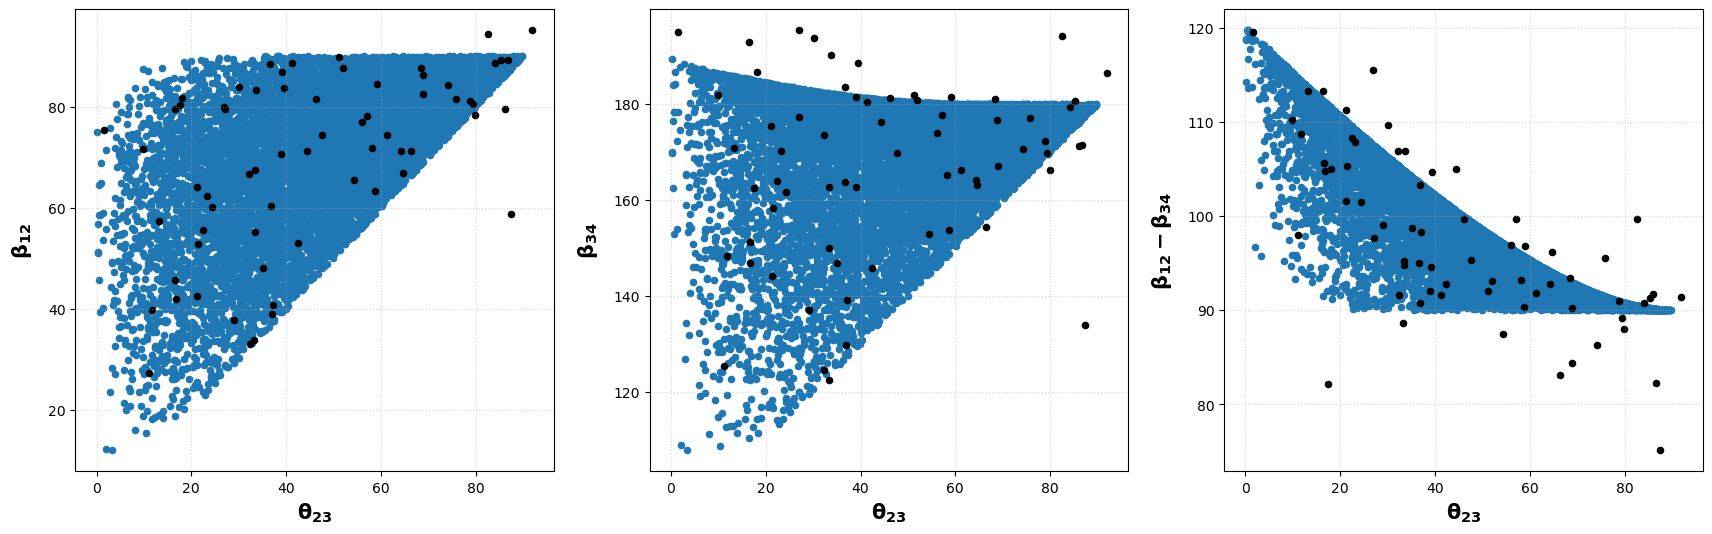

In [25]:
#> initializing plot
fig, axes = plt.subplots(1,3,figsize=(3*6+3, 6))
bins = 20
keys = ['b12', 'b34', 'b12-b34']
labels = [r'$\mathbf{\beta_{12}}$', r'$\mathbf{\beta_{34}}$', r'$\mathbf{\beta_{12}-\beta_{34}}$']
for key, label, ax in zip(keys, labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_ylabel(label, fontsize=15, labelpad=10)
    ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=15)
    ax.scatter(df['t23'], df[key], bins)

for key, label, ax in zip(keys, labels, axes.flat):
    ax.grid(ls=':', alpha=0.5)
    ax.set_ylabel(label, fontsize=15, labelpad=10)
    ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=15)
    ax.scatter(obs_df['t23'], obs_df[key], bins, c='k')
plt.savefig('./figs/mock_bisector_t23.png', bbox_inches='tight', dpi=100)

In [18]:
#> loading in other data
file = '2605281629messedup.npy'
data = np.load(file, allow_pickle=True)
observables = ['t12', 't23', 't34', 'd2/d1', 'd3/d1' ,'d4/d1', 'dt23']
df = pd.DataFrame(data, columns=observables)
df = df[ df['dt23'].apply(abs) < 20 ]

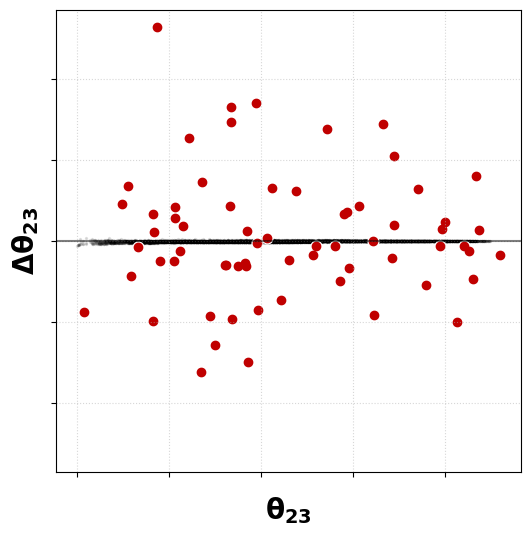

In [27]:
#> plotting 2D FSQ
c = '#C00000'
fontsize=20
nquads = len(obs_df['t23'].to_numpy())
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.grid(ls=':', alpha=0.5)
# ax.set_title(f'All Quad Lenses (N={nquads})', fontsize=fontsize, fontweight='bold')
ax.set_xlabel(r'$\mathbf{\theta_{23}}$', fontsize=fontsize, labelpad=10)
ax.set_ylabel(r'$\mathbf{\Delta\theta_{23}}$', fontsize=fontsize)
ax.axhline(0, c='k', alpha=0.5)


ax.scatter(df['t23'], df['dt23'], c='k', alpha=0.1, s=2)
ax.scatter(obs_df['t23'], obs_df['dt23'], c='w', s=60)
ax.scatter(obs_df['t23'], obs_df['dt23'], c=c)
ax.set_xticklabels([])
ax.set_yticklabels({})

miny, maxy = ax.get_ylim()
bound = max(abs(miny), maxy)
ax.set_ylim(-bound, bound)

plt.savefig('./figs/obs_2DFSQ_comparison.png', bbox_inches='tight', dpi=100)
plt.show()